# Traditional chatbot with persistent memory

In [10]:
from langchain_ollama import ChatOllama 
from langgraph.graph import MessagesState
import sqlite3
from pydantic import BaseModel, Field, ValidationError
from typing_extensions import TypedDict
from typing import Annotated, Literal
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import trim_messages, SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
class ChatbotConfig(BaseModel): 
    # Pydantic enforcement 
    model_name : str = Field(default="llama3.2:1b", description="Default model we are using")
    temperature : float = Field(default=0.1)
    max_history_tokens : int = Field(default=2048) 
    db_path : str = Field(default="chatbot_memory.db")

try:
    error_config = ChatbotConfig(temperature="Hello")
except ValidationError as e:
    print("Pydantic error caught", e)


config = ChatbotConfig(model_name="llama3.1:1b")

Pydantic error caught 1 validation error for ChatbotConfig
temperature
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='Hello', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing


* **State** is the shared memory between graphs 
* **Reducer** Tells langraph how to update the state. Without any reducer the value would be overwritten for each call ig to the list. With this langgraph updates the new messages to the existing history. 
* **Trimming** Truncate messages before passing them to the chat model 
* **Checkpointer** save the graph state to disk

In [7]:
class AgenticChatbot:
    def __init__(self, config:ChatbotConfig):
        # load config and initialize chatbot
        self.config = config 
        self.llm = ChatOllama(model = self.config.model_name,
                              temperature=self.config.temperature)
        
        # Define state schema internally
        class State(TypedDict):
            messages : Annotated[list, add_messages]
        self.State = State 

        self.conn = sqlite3.connect(self.config.db_path, 
                                    check_same_thread=False) 
        self.checkpointer = SqliteSaver(self.conn)

        self.graph = self.build_graph()

    def trim_history(self, messages:list) -> list:
        """
        Trim messages 
        Exact no of tokens depend upon the tokenizer
        Using langchains built in token counter or some other appropriate logic
        """

        def word_counter(msgs) -> int: 
            return sum(len(m.content.split()) for m in msgs)
        
        trimmer = trim_messages(
            max_tokens = self.config.max_history_tokens,
            strategy = "last", #Keep the most recent tokens 
            token_counter = word_counter, 
            include_system = True, #never trim system messages 
            allow_partial=False 
        )
        return trimmer.invoke(messages)
    
    def chatbot_node(self, state:dict):
        # Main node that processes the state and calls the llm 
        messages = state["messages"] 
        trimmed_messages = self.trim_history(messages)
        response = self.llm.invoke(trimmed_messages)
        return {"messages" : [response]}
    
    def build_graph(self):
        builder = StateGraph(self.State)

        builder.add_node("chat_model", self.chatbot_node)
        builder.add_edge(START, "chat_model")
        builder.add_edge("chat_model", END)

        return builder.compile(checkpointer=self.checkpointer) 
    
    def chat(self, user_input: str, thread_id : str = "default_thread"):
        #Langgraph uses thread id's to separate different conversations in memory
        thread_config = {"configurable": {"thread_id" : thread_id}}

        # input state must match the State Schema 
        input_state = {"messages" :  [HumanMessage(content=user_input)]}

        #Stream the output to see it as the tokens are generated 
        for event in self.graph.stream(input_state, config=thread_config):
            for value in event.values():
                print("Bot:", value["messages"][-1].content)

In [9]:
bot = AgenticChatbot(config=ChatbotConfig(model_name = "llama3.2:1b",
                                          max_history_tokens=128))

print("----Turn 1---")
bot.chat("Hi my name is Leon. Favorite color is green", thread_id="user1")

print("---Turn 2---")
bot.chat("What is my favorite color ?", thread_id="user1")

print("---Turn 3--- [New Thread]")
bot.chat("Do you know my name ?", thread_id="user256")

----Turn 1---
Bot: Nice to meet you, Leon! It sounds like you have a great sense of style and appreciate the natural world. Green is a wonderful favorite color - it's so calming and refreshing. What do you like to do for fun, or what are some of your hobbies?
---Turn 2---
Bot: Your favorite color is green!
---Turn 3--- [New Thread]
Bot: I'm not capable of knowing your name or any other personal information about you. I'm a large language model, I don't have the ability to store or access any personal data about individuals. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I'll do my best to remember it for our conversation today.


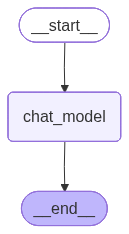

In [11]:
#display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(bot.graph.get_graph().draw_mermaid_png()))
